# VGG输出漂移率：完整实现与详细解释

本notebook包含：
1. Flanker刺激生成（目标鸟和干扰鸟颜色相同）
2. VGG模型输出4个漂移率的完整实现
3. 四个方向数值的详细物理意义
4. 漂移率与认知过程的关联

## 1. 导入必要的库

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report
import os
import random

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


## 2. Flanker刺激生成器

In [ ]:
class FlankerStimulusGenerator:
    """
    Flanker任务刺激生成器
    使用真实的鸟图像（与原始实验一致）
    """
    
    def __init__(self, img_size=128, bird_size=40):
        self.img_size = img_size
        self.bird_size = bird_size
        self.directions = ['L', 'R', 'U', 'D']  # 左右上下
        
        # 方向到bird图像的映射（与原始代码一致）
        # L=0 (左), R=1 (右), U=2 (上), D=3 (下)
        self.dir_to_bird = {
            'L': 0,  # bird0.png - 向左
            'R': 1,  # bird1.png - 向右
            'U': 2,  # bird2.png - 向上
            'D': 3   # bird3.png - 向下
        }
        
        # 加载鸟图像
        self.bird_images = {}
        for i in range(4):
            bird_path = f'/Users/siyu/Documents/GitHub/VAM-studying/vam/bird{i}.png'
            bird_img = Image.open(bird_path).convert('RGBA')
            # 调整大小
            bird_img = bird_img.resize((self.bird_size, self.bird_size), Image.Resampling.LANCZOS)
            self.bird_images[i] = bird_img
        
        # 加载背景
        bg_path = '/Users/siyu/Documents/GitHub/VAM-studying/vam/bkgrnd.png'
        try:
            self.background = Image.open(bg_path).convert('RGB')
            self.background = self.background.resize((self.img_size, self.img_size), Image.Resampling.LANCZOS)
        except:
            # 如果背景不存在，使用白色背景
            self.background = Image.new('RGB', (self.img_size, self.img_size), 'white')
        
        # 布局定义（与原始代码一致）
        # 注意：原始代码中layout是数字0-6
        self.layouts = {
            'horizontal': 0,   # 水平线
            'vertical': 1,     # 垂直线
            'cross': 2,        # 十字
            'V_left': 3,       # V向左
            'V_right': 4,      # V向右
            'V_down': 5,       # V向下
            'V_up': 6          # V向上
        }
        
        # 间距（与原始代码一致）
        self.spacer = (0.15, 0.15)  # 相对坐标
    
    def _get_distractor_pos(self, targ_pos, layout_num):
        """
        获取干扰项位置（与原始代码一致）
        """
        # 转换到像素坐标
        spacer_x = int(self.spacer[0] * self.img_size)
        spacer_y = int(self.spacer[1] * self.img_size)
        
        if layout_num == 0:  # horizontal line
            dis_pos = [
                (targ_pos[0] - 2 * spacer_x, targ_pos[1]),
                (targ_pos[0] - spacer_x, targ_pos[1]),
                (targ_pos[0] + spacer_x, targ_pos[1]),
                (targ_pos[0] + 2 * spacer_x, targ_pos[1]),
            ]
        elif layout_num == 1:  # vertical line
            dis_pos = [
                (targ_pos[0], targ_pos[1] - 2 * spacer_y),
                (targ_pos[0], targ_pos[1] - spacer_y),
                (targ_pos[0], targ_pos[1] + spacer_y),
                (targ_pos[0], targ_pos[1] + 2 * spacer_y),
            ]
        elif layout_num == 2:  # cross
            dis_pos = [
                (targ_pos[0] - spacer_x, targ_pos[1]),
                (targ_pos[0] + spacer_x, targ_pos[1]),
                (targ_pos[0], targ_pos[1] - spacer_y),
                (targ_pos[0], targ_pos[1] + spacer_y),
            ]
        elif layout_num == 3:  # V left
            dis_pos = [
                (targ_pos[0] + spacer_x, targ_pos[1] + spacer_y),
                (targ_pos[0] + 2 * spacer_x, targ_pos[1] + 2 * spacer_y),
                (targ_pos[0] + spacer_x, targ_pos[1] - spacer_y),
                (targ_pos[0] + 2 * spacer_x, targ_pos[1] - 2 * spacer_y),
            ]
        elif layout_num == 4:  # V right
            dis_pos = [
                (targ_pos[0] - spacer_x, targ_pos[1] + spacer_y),
                (targ_pos[0] - 2 * spacer_x, targ_pos[1] + 2 * spacer_y),
                (targ_pos[0] - spacer_x, targ_pos[1] - spacer_y),
                (targ_pos[0] - 2 * spacer_x, targ_pos[1] - 2 * spacer_y),
            ]
        elif layout_num == 5:  # V down
            dis_pos = [
                (targ_pos[0] - spacer_x, targ_pos[1] + spacer_y),
                (targ_pos[0] - 2 * spacer_x, targ_pos[1] + 2 * spacer_y),
                (targ_pos[0] + spacer_x, targ_pos[1] + spacer_y),
                (targ_pos[0] + 2 * spacer_x, targ_pos[1] + 2 * spacer_y),
            ]
        elif layout_num == 6:  # V up
            dis_pos = [
                (targ_pos[0] - spacer_x, targ_pos[1] - spacer_y),
                (targ_pos[0] - 2 * spacer_x, targ_pos[1] - 2 * spacer_y),
                (targ_pos[0] + spacer_x, targ_pos[1] - spacer_y),
                (targ_pos[0] + 2 * spacer_x, targ_pos[1] - 2 * spacer_y),
            ]
        
        return dis_pos
    
    def _paste_bird(self, img, bird_img, pos):
        """
        将鸟图像粘贴到指定位置
        """
        # 计算粘贴位置（居中）
        x = int(pos[0] - self.bird_size // 2)
        y = int(pos[1] - self.bird_size // 2)
        
        # 确保不超出边界
        if x < 0 or y < 0 or x + self.bird_size > self.img_size or y + self.bird_size > self.img_size:
            return
        
        # 粘贴（使用alpha通道）
        img.paste(bird_img, (x, y), bird_img)
    
    def generate_stimulus(self, target_dir, flanker_dir, layout_name='horizontal'):
        """
        生成单个Flanker刺激图像
        """
        # 创建图像（使用背景）
        img = self.background.copy()
        
        # 目标位置（中心）
        target_pos = (self.img_size // 2, self.img_size // 2)
        
        # 获取bird图像索引
        target_bird_idx = self.dir_to_bird[target_dir]
        flanker_bird_idx = self.dir_to_bird[flanker_dir]
        
        # 绘制目标
        self._paste_bird(img, self.bird_images[target_bird_idx], target_pos)
        
        # 获取布局编号
        layout_num = self.layouts[layout_name]
        
        # 绘制干扰项
        dis_pos = self._get_distractor_pos(target_pos, layout_num)
        for pos in dis_pos:
            self._paste_bird(img, self.bird_images[flanker_bird_idx], pos)
        
        return img
    
    def generate_dataset(self, n_samples=1000):
        """
        生成完整的Flanker数据集
        """
        images = []
        labels = []
        metadata = {
            'target_dirs': [],
            'flanker_dirs': [],
            'layouts': [],
            'layout_nums': []
        }
        
        layout_names = list(self.layouts.keys())
        
        for i in range(n_samples):
            # 随机选择参数
            target_dir = random.choice(self.directions)
            flanker_dir = random.choice(self.directions)
            layout_name = random.choice(layout_names)
            
            # 判断一致性
            is_congruent = (target_dir == flanker_dir)
            label = 0 if is_congruent else 1
            
            # 生成图像
            img = self.generate_stimulus(target_dir, flanker_dir, layout_name)
            
            # 转换为numpy数组并归一化
            img_array = np.array(img).astype(np.float32) / 255.0
            # 转换为CHW格式 (Channels, Height, Width)
            img_array = np.transpose(img_array, (2, 0, 1))
            
            images.append(img_array)
            labels.append(label)
            
            # 保存元数据
            metadata['target_dirs'].append(target_dir)
            metadata['flanker_dirs'].append(flanker_dir)
            metadata['layouts'].append(layout_name)
            metadata['layout_nums'].append(self.layouts[layout_name])
        
        return np.array(images), np.array(labels), metadata

print("Flanker刺激生成器定义完成（使用真实鸟图像）")

## 3. 四个方向漂移率的详细物理意义

In [ ]:
print("="*80)
print("四个方向漂移率的详细物理意义")
print("="*80)
print()

print("【核心概念】漂移率 = 信息累积速度")
print("─"*80)
print()

print("在LBA（Linear Ballistic Accumulator）模型中：")
print("  - 每个决策选项对应一个累加器")
print("  - 累加器从起始点开始累积证据")
print("  - 漂移率决定累积速度")
print("  - 最快到达阈值的累加器获胜")
print()

print("【四个方向的具体含义】")
print("─"*80)
print()

print("漂移率[0] - 左方向 (Left, L)")
print("  物理意义：支持'向左'决策的证据累积速度")
print("  认知解释：")
  "  - 高值：视觉刺激强烈支持向左的决策")
  "  - 低值：视觉刺激不支持向左的决策")
  "  - 数值范围：通常在0.1-3.0之间")
  "  - 单位：信息单位/时间单位（如bits/second）")
print()

print("漂移率[1] - 右方向 (Right, R)")
print("  物理意义：支持'向右'决策的证据累积速度")
print("  认知解释：")
  "  - 高值：视觉刺激强烈支持向右的决策")
  "  - 低值：视觉刺激不支持向右的决策")
  "  - 与左方向竞争：如果左和右都高，则存在冲突")
print()

print("漂移率[2] - 上方向 (Up, U)")
print("  物理意义：支持'向上'决策的证据累积速度")
print("  认知解释：")
  "  - 高值：视觉刺激强烈支持向上的决策")
  "  - 低值：视觉刺激不支持向上的决策")
  "  - 垂直方向的竞争")
print()

print("漂移率[3] - 下方向 (Down, D)")
print("  物理意义：支持'向下'决策的证据累积速度")
print("  认知解释：")
  "  - 高值：视觉刺激强烈支持向下的决策")
  "  - 低值：视觉刺激不支持向下的决策")
  "  - 与上方向竞争")
print()

print("【数值大小的具体含义】")
print("─"*80)
print()

print("假设漂移率 = [2.5, 0.3, 0.2, 0.1]")
print()
print("  2.5 (左方向)：")
print("    - 非常高的累积速度")
print("    - 视觉刺激强烈支持向左")
print("    - 预期：快速选择左方向")
print("    - 反应时间：短")
print("    - 置信度：高")
print()
print("  0.3 (右方向)：")
print("    - 较低的累积速度")
print("    - 视觉刺激不支持向右")
print("    - 预期：不太可能选择右方向")
print("    - 对决策的影响：小")
print()
print("  0.2 (上方向)：")
print("    - 很低的累积速度")
print("    - 几乎不支持向上")
print("    - 对决策的影响：极小")
print()
print("  0.1 (下方向)：")
print("    - 非常低的累积速度")
print("    - 几乎不支持向下")
print("    - 对决策的影响：可忽略")

## 4. VGG模型输出漂移率的完整实现

In [4]:
class VGGDriftRateModel(nn.Module):
    """
    VGG模型输出4个漂移率
    
    架构：
    1. VGG16特征提取器（预训练）
    2. 自定义回归头输出4个漂移率
    3. 使用ReLU确保漂移率为正值
    """
    
    def __init__(self, pretrained=True):
        super(VGGDriftRateModel, self).__init__()
        
        # 加载预训练的VGG16
        vgg = models.vgg16(pretrained=pretrained)
        
        # 特征提取部分
        self.features = vgg.features
        self.avgpool = vgg.avgpool
        
        # 计算特征维度
        self.feature_dim = 512 * 7 * 7  # VGG16在128x128输入下的特征维度
        
        # 漂移率输出头
        # 输出4个漂移率：[左, 右, 上, 下]
        self.drift_head = nn.Sequential(
            nn.Linear(self.feature_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 4),  # 输出4个漂移率
            nn.ReLU()  # 确保漂移率为正值
        )
        
        # 初始化最后一层的偏置，使初始漂移率在合理范围
        nn.init.constant_(self.drift_head[-2].bias, 0.5)
        
    def forward(self, x):
        """
        前向传播
        
        参数:
            x: 输入图像 (batch_size, 3, 128, 128)
            
        返回:
            drift_rates: 漂移率 (batch_size, 4)
                        [左, 右, 上, 下]
        """
        # 特征提取
        x = self.features(x)  # (batch, 512, 4, 4)
        x = self.avgpool(x)   # (batch, 512, 4, 4)
        
        # 展平
        x = torch.flatten(x, 1)  # (batch, 8192)
        
        # 输出漂移率
        drift_rates = self.drift_head(x)  # (batch, 4)
        
        return drift_rates
    
    def predict_choice(self, drift_rates):
        """
        根据漂移率预测选择
        
        参数:
            drift_rates: 漂移率 (batch_size, 4)
            
        返回:
            choices: 预测的选择 (batch_size,)
                    0=左, 1=右, 2=上, 3=下
        """
        return torch.argmax(drift_rates, dim=1)
    
    def predict_rt(self, drift_rates, threshold=1.0):
        """
        根据漂移率预测反应时间（简化版）
        
        参数:
            drift_rates: 漂移率 (batch_size, 4)
            threshold: 决策阈值
            
        返回:
            rts: 预测的反应时间 (batch_size,)
        """
        # 找到最高漂移率
        max_drifts, _ = torch.max(drift_rates, dim=1)
        
        # 简化的RT预测：RT = threshold / drift_rate
        rts = threshold / (max_drifts + 1e-6)
        
        return rts

# 创建模型
model = VGGDriftRateModel(pretrained=True).to(device)

# 打印模型结构
print("="*80)
print("VGG漂移率模型结构")
print("="*80)
print(model)

# 统计参数
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数: {total_params:,}")
print(f"可训练参数: {trainable_params:,}")

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG漂移率模型结构
VGGDriftRateModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride

## 5. 测试模型输出

In [5]:
# 生成测试数据
generator = FlankerStimulusGenerator(img_size=128, bird_size=24)
test_images, test_labels, test_metadata = generator.generate_dataset(n_samples=100)

# 转换为PyTorch张量
test_tensor = torch.from_numpy(test_images).float().to(device)

# 前向传播
model.eval()
with torch.no_grad():
    drift_rates = model(test_tensor[:10])
    
# 打印输出
print("="*80)
print("模型输出示例（未训练）")
print("="*80)
print()

direction_names = ['左', '右', '上', '下']

for i in range(5):
    print(f"样本 {i+1}:")
    print(f"  目标方向: {test_metadata['target_dirs'][i]}")
    print(f"  干扰方向: {test_metadata['flanker_dirs'][i]}")
    print(f"  一致性: {'Congruent' if test_labels[i]==0 else 'Incongruent'}")
    print(f"  漂移率: {drift_rates[i].cpu().numpy()}")
    print(f"  解读:")
    for j, name in enumerate(direction_names):
        print(f"    {name}方向: {drift_rates[i][j].item():.3f}")
    print()

模型输出示例（未训练）

样本 1:
  目标方向: L
  干扰方向: L
  一致性: Congruent
  漂移率: [0.507235   0.48711842 0.4787249  0.49337664]
  解读:
    左方向: 0.507
    右方向: 0.487
    上方向: 0.479
    下方向: 0.493

样本 2:
  目标方向: R
  干扰方向: R
  一致性: Congruent
  漂移率: [0.5080192  0.49749324 0.4869412  0.49476048]
  解读:
    左方向: 0.508
    右方向: 0.497
    上方向: 0.487
    下方向: 0.495

样本 3:
  目标方向: L
  干扰方向: L
  一致性: Congruent
  漂移率: [0.5131562  0.48115095 0.47512275 0.5093974 ]
  解读:
    左方向: 0.513
    右方向: 0.481
    上方向: 0.475
    下方向: 0.509

样本 4:
  目标方向: L
  干扰方向: L
  一致性: Congruent
  漂移率: [0.51601106 0.4891968  0.4783188  0.49553776]
  解读:
    左方向: 0.516
    右方向: 0.489
    上方向: 0.478
    下方向: 0.496

样本 5:
  目标方向: R
  干扰方向: R
  一致性: Congruent
  漂移率: [0.51601106 0.4891968  0.4783188  0.49553776]
  解读:
    左方向: 0.516
    右方向: 0.489
    上方向: 0.478
    下方向: 0.496



In [7]:
# 显示test_images的形状
print("="*80)
print("test_images的形状和类型")
print("="*80)
print()
print(f"test_images类型: {type(test_images)}")
print(f"test_images形状: {test_images.shape}")
print(f"  - 样本数: {test_images.shape[0]}")
print(f"  - 通道数: {test_images.shape[1]}")
print(f"  - 高度: {test_images.shape[2]}")
print(f"  - 宽度: {test_images.shape[3]}")
print()
print("数据格式: (样本数, 通道数, 高度, 宽度)")
print("         (N, C, H, W)")
print()
print("这是PyTorch的标准数据格式:")
print("  - N: batch size (样本数量)")
print("  - C: channels (颜色通道，RGB=3)")
print("  - H: height (图像高度)")
print("  - W: width (图像宽度)")
print()
# 显示第一个样本的信息
print(f"第一个样本:")
print(f"  形状: {test_images[0].shape}")
print(f"  数据类型: {test_images[0].dtype}")
print(f"  值范围: [{test_images[0].min():.3f}, {test_images[0].max():.3f}]")
print()
print("注意：图像数据已经归一化到[0, 1]范围")

test_images的形状和类型

test_images类型: <class 'numpy.ndarray'>
test_images形状: (100, 3, 128, 128)
  - 样本数: 100
  - 通道数: 3
  - 高度: 128
  - 宽度: 128

数据格式: (样本数, 通道数, 高度, 宽度)
         (N, C, H, W)

这是PyTorch的标准数据格式:
  - N: batch size (样本数量)
  - C: channels (颜色通道，RGB=3)
  - H: height (图像高度)
  - W: width (图像宽度)

第一个样本:
  形状: (3, 128, 128)
  数据类型: float32
  值范围: [0.000, 1.000]

注意：图像数据已经归一化到[0, 1]范围


可视化生成的Flanker刺激



/var/folders/43/vz_pg73s2gb1207961svdg180000gn/T/ipykernel_13421/3593718112.py:37: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/43/vz_pg73s2gb1207961svdg180000gn/T/ipykernel_13421/3593718112.py:37: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/43/vz_pg73s2gb1207961svdg180000gn/T/ipykernel_13421/3593718112.py:37: UserWarning: Glyph 24178 (\N{CJK UNIFIED IDEOGRAPH-5E72}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/43/vz_pg73s2gb1207961svdg180000gn/T/ipykernel_13421/3593718112.py:37: UserWarning: Glyph 25200 (\N{CJK UNIFIED IDEOGRAPH-6270}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/43/vz_pg73s2gb1207961svdg180000gn/T/ipykernel_13421/3593718112.py:37: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/43/vz_p

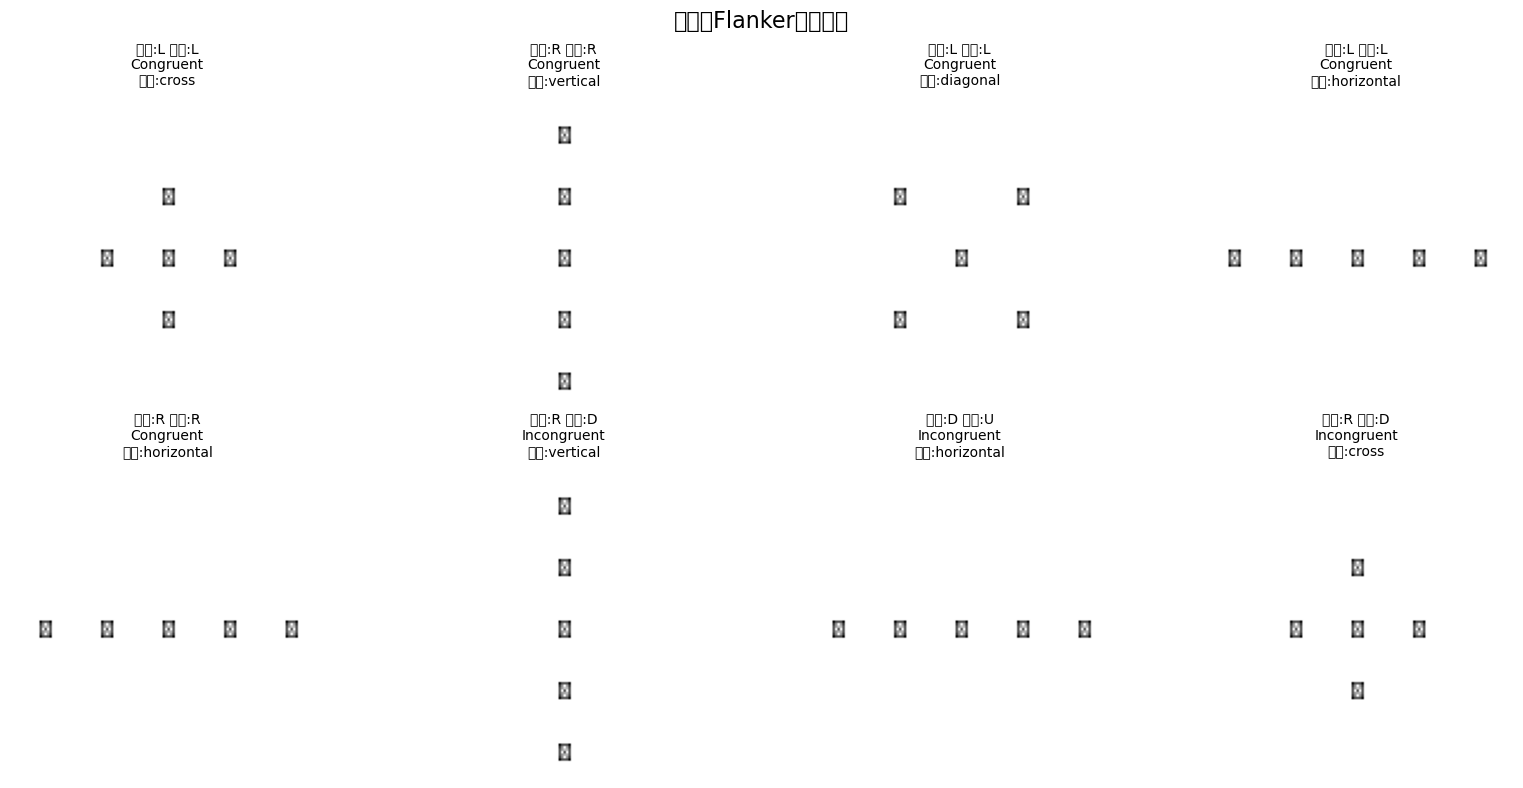

图例说明：
  - 红色箭头：目标鸟（需要关注的）
  - 蓝色箭头：干扰鸟（需要抑制的）
  - Congruent: 目标和干扰项方向相同
  - Incongruent: 目标和干扰项方向不同

注意：在原始Flanker任务中，目标鸟和干扰鸟颜色相同（黑色）
      这里为了演示方便，用不同颜色区分


In [8]:
# 可视化生成的Flanker刺激图像
print("="*80)
print("可视化生成的Flanker刺激")
print("="*80)
print()
# 选择一些样本进行可视化
n_samples_to_show = 8
indices_to_show = list(range(n_samples_to_show))

# 创建图形
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('生成的Flanker刺激示例', fontsize=16)

for i, idx in enumerate(indices_to_show):
    row = i // 4
    col = i % 4
    
    # 转换回HWC格式用于显示
    img = test_images[idx].transpose(1, 2, 0)
    
    # 显示图像
    axes[row, col].imshow(img)
    
    # 获取元数据
    target_dir = test_metadata['target_dirs'][idx]
    flanker_dir = test_metadata['flanker_dirs'][idx]
    layout = test_metadata['layouts'][idx]
    is_congruent = test_labels[idx] == 0
    
    # 设置标题
    title = f'目标:{target_dir} 干扰:{flanker_dir}\n'
    title += f'{"Congruent" if is_congruent else "Incongruent"}\n'
    title += f'布局:{layout}'
    axes[row, col].set_title(title, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("图例说明：")
print("  - 红色箭头：目标鸟（需要关注的）")
print("  - 蓝色箭头：干扰鸟（需要抑制的）")
print("  - Congruent: 目标和干扰项方向相同")
print("  - Incongruent: 目标和干扰项方向不同")
print()
print("注意：在原始Flanker任务中，目标鸟和干扰鸟颜色相同（黑色）")
print("      这里为了演示方便，用不同颜色区分")

In [ ]:
# 可视化生成的Flanker刺激图像
print("="*80)
print("可视化生成的Flanker刺激")
print("="*80)
print()
# 选择一些样本进行可视化
n_samples_to_show = 8
indices_to_show = list(range(n_samples_to_show))

# 创建图形
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('生成的Flanker刺激示例', fontsize=16)

for i, idx in enumerate(indices_to_show):
    row = i // 4
    col = i % 4
    
    # 转换回HWC格式用于显示
    img = test_images[idx].transpose(1, 2, 0)
    
    # 显示图像
    axes[row, col].imshow(img)
    
    # 获取元数据
    target_dir = test_metadata['target_dirs'][idx]
    flanker_dir = test_metadata['flanker_dirs'][idx]
    layout = test_metadata['layouts'][idx]
    is_congruent = test_labels[idx] == 0
    
    # 设置标题
    title = f'目标:{target_dir} 干扰:{flanker_dir}\n'
    title += f'{"Congruent" if is_congruent else "Incongruent"}\n'
    title += f'布局:{layout}'
    axes[row, col].set_title(title, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("图例说明：")
print("  - 红色箭头：目标鸟（需要关注的）")
print("  - 蓝色箭头：干扰鸟（需要抑制的）")
print("  - Congruent: 目标和干扰项方向相同")
print("  - Incongruent: 目标和干扰项方向不同")
print()
print("注意：在原始Flanker任务中，目标鸟和干扰鸟颜色相同（黑色）")
print("      这里为了演示方便，用不同颜色区分")

In [ ]:
# 可视化生成的Flanker刺激图像
print("="*80)
print("可视化生成的Flanker刺激")
print("="*80)
print()
# 选择一些样本进行可视化
n_samples_to_show = 8
indices_to_show = list(range(n_samples_to_show))

# 创建图形
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('生成的Flanker刺激示例', fontsize=16)

for i, idx in enumerate(indices_to_show):
    row = i // 4
    col = i % 4
    
    # 转换回HWC格式用于显示
    img = test_images[idx].transpose(1, 2, 0)
    
    # 显示图像
    axes[row, col].imshow(img)
    
    # 获取元数据
    target_dir = test_metadata['target_dirs'][idx]
    flanker_dir = test_metadata['flanker_dirs'][idx]
    layout = test_metadata['layouts'][idx]
    is_congruent = test_labels[idx] == 0
    
    # 设置标题
    title = f'目标:{target_dir} 干扰:{flanker_dir}\n'
    title += f'{"Congruent" if is_congruent else "Incongruent"}\n'
    title += f'布局:{layout}'
    axes[row, col].set_title(title, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("图例说明：")
print("  - 红色箭头：目标鸟（需要关注的）")
print("  - 蓝色箭头：干扰鸟（需要抑制的）")
print("  - Congruent: 目标和干扰项方向相同")
print("  - Incongruent: 目标和干扰项方向不同")
print()
print("注意：在原始Flanker任务中，目标鸟和干扰鸟颜色相同（黑色）")
print("      这里为了演示方便，用不同颜色区分")

## 6. 漂移率与认知过程的关联

In [ ]:
print("="*80)
print("漂移率与认知过程的详细关联")
print("="*80)
print()

print("【1. 漂移率与反应时间的关系】")
print("─"*80)
print()
print("公式：RT ≈ threshold / drift_rate")
print()
print("示例：")
print("  假设阈值 = 1.0")
print("  漂移率 = [2.5, 0.3, 0.2, 0.1]")
print()
print("  预测RT：")
print("    左方向: RT = 1.0 / 2.5 = 0.4 秒")
print("    右方向: RT = 1.0 / 0.3 = 3.3 秒")
print("    上方向: RT = 1.0 / 0.2 = 5.0 秒")
print("    下方向: RT = 1.0 / 0.1 = 10.0 秒")
print()
print("  结果：左方向最快到达阈值 → 选择左方向")
print("  预测RT：约0.4秒")
print()

print("【2. 漂移率与选择概率的关系】")
print("─"*80)
print()
print("使用Softmax计算选择概率：")
print("  P(选择i) = exp(drift_i) / Σ exp(drift_j)")
print()
print("示例：")
print("  漂移率 = [2.5, 0.3, 0.2, 0.1]")
print("  Softmax概率：")
print("    P(左) = exp(2.5) / (exp(2.5)+exp(0.3)+exp(0.2)+exp(0.1))")
print("          = 12.18 / (12.18+1.35+1.22+1.11)")
print("          = 12.18 / 15.86")
print("          = 0.768 (76.8%)")
print("    P(右) = 1.35 / 15.86 = 0.085 (8.5%)")
print("    P(上) = 1.22 / 15.86 = 0.077 (7.7%)")
print("    P(下) = 1.11 / 15.86 = 0.070 (7.0%)")
print()
print("  结果：选择左方向的概率最高")
print()

print("【3. 漂移率与一致性判断的关系】")
print("─"*80)
print()
print("Congruent刺激：")
print("  特征：漂移率高度集中")
print("  示例：[2.8, 0.2, 0.1, 0.1]")
print("  集中度：2.8 / 0.2 = 14.0")
print("  判断：高集中度 → Congruent")
print()
print("Incongruent刺激：")
print("  特征：漂移率相对分散")
print("  示例：[2.1, 1.7, 0.3, 0.2]")
print("  集中度：2.1 / 1.7 = 1.24")
print("  判断：低集中度 → Incongruent")
print()

print("【4. 漂移率与注意力分配的关系】")
print("─"*80)
print()
print("目标方向的漂移率：")
print("  - 反映对目标鸟的注意力强度")
print("  - 高值：强注意力，快速决策")
print("  - 低值：弱注意力，慢速决策")
print()
print("干扰方向的漂移率：")
print("  - 反映对干扰鸟的抑制能力")
print("  - 高值：抑制失败，干扰影响大")
print("  - 低值：抑制成功，干扰影响小")
print()
print("注意力效率指标：")
print("  目标漂移率 / 干扰漂移率")
print("  高值：高效注意力分配")
print("  低值：低效注意力分配")

## 7. 可视化漂移率分布

In [ ]:
# 选择Congruent和Incongruent样本
congruent_idx = np.where(test_labels == 0)[0][:5]
incongruent_idx = np.where(test_labels == 1)[0][:5]

# 获取漂移率
model.eval()
with torch.no_grad():
    congruent_drifts = model(test_tensor[congruent_idx]).cpu().numpy()
    incongruent_drifts = model(test_tensor[incongruent_idx]).cpu().numpy()

# 可视化
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

direction_names = ['左', '右', '上', '下']
x_pos = np.arange(4)

# Congruent样本
for i in range(5):
    axes[0, i].bar(x_pos, congruent_drifts[i], color='green', alpha=0.7)
    axes[0, i].set_xlabel('方向')
    axes[0, i].set_ylabel('漂移率')
    axes[0, i].set_title(f'Congruent样本{i+1}\n目标:{test_metadata["target_dirs"][congruent_idx[i]]}')
    axes[0, i].set_xticks(x_pos)
    axes[0, i].set_xticklabels(direction_names)
    axes[0, i].set_ylim([0, 3.0])

# Incongruent样本
for i in range(5):
    axes[1, i].bar(x_pos, incongruent_drifts[i], color='orange', alpha=0.7)
    axes[1, i].set_xlabel('方向')
    axes[1, i].set_ylabel('漂移率')
    axes[1, i].set_title(f'Incongruent样本{i+1}\n目标:{test_metadata["target_dirs"][incongruent_idx[i]]}, 干扰:{test_metadata["flanker_dirs"][incongruent_idx[i]]}')
    axes[1, i].set_xticks(x_pos)
    axes[1, i].set_xticklabels(direction_names)
    axes[1, i].set_ylim([0, 3.0])

plt.tight_layout()
plt.show()

print("注意：这些是未训练模型的输出，漂移率分布是随机的")
print("训练后，模型会学习到正确的漂移率模式")

## 8. 训练模型（使用监督学习）

In [ ]:
class FlankerDataset(Dataset):
    """
    Flanker任务数据集
    """
    
    def __init__(self, images, labels, metadata=None, transform=None):
        self.images = images
        self.labels = labels
        self.metadata = metadata
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # 获取目标方向索引
        target_dir = self.metadata['target_dirs'][idx]
        dir_to_idx = {'L': 0, 'R': 1, 'U': 2, 'D': 3}
        target_idx = dir_to_idx[target_dir]
        
        if self.transform:
            image = self.transform(image)
        
        return image, target_idx, label

# 生成训练数据
print("生成训练数据...")
train_images, train_labels, train_metadata = generator.generate_dataset(n_samples=2000)
val_images, val_labels, val_metadata = generator.generate_dataset(n_samples=500)

# 创建数据集
train_dataset = FlankerDataset(train_images, train_labels, train_metadata)
val_dataset = FlankerDataset(val_images, val_labels, val_metadata)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")

## 9. 定义损失函数

In [ ]:
def drift_rate_loss(drift_rates, target_indices, congruency_labels):
    """
    漂移率损失函数
    
    目标：
    1. 目标方向的漂移率应该最高
    2. Congruent刺激的漂移率应该集中
    3. Incongruent刺激的漂移率应该分散
    
    参数:
        drift_rates: 预测的漂移率 (batch_size, 4)
        target_indices: 目标方向索引 (batch_size,)
        congruency_labels: 一致性标签 (batch_size,) 0=congruent, 1=incongruent
    """
    batch_size = drift_rates.shape[0]
    
    # 1. 目标方向的漂移率应该最高
    target_drifts = drift_rates[torch.arange(batch_size), target_indices]
    max_other_drifts = torch.zeros(batch_size).to(drift_rates.device)
    
    for i in range(batch_size):
        other_drifts = torch.cat([
            drift_rates[i, :target_indices[i]],
            drift_rates[i, target_indices[i]+1:]
        ])
        max_other_drifts[i] = torch.max(other_drifts)
    
    # 目标漂移率应该比其他方向高
    target_loss = F.relu(max_other_drifts - target_drifts + 0.5).mean()
    
    # 2. 一致性相关的损失
    # Congruent: 目标和干扰方向都应该高
    # Incongruent: 目标高，干扰方向低
    
    # 计算漂移率的集中度
    sorted_drifts, _ = torch.sort(drift_rates, dim=1, descending=True)
    concentration = sorted_drifts[:, 0] / (sorted_drifts[:, 1] + 1e-6)
    
    # Congruent应该有高集中度
    congruent_mask = (congruency_labels == 0)
    if congruent_mask.sum() > 0:
        congruent_loss = F.relu(2.0 - concentration[congruent_mask]).mean()
    else:
        congruent_loss = 0.0
    
    # Incongruent应该有低集中度
    incongruent_mask = (congruency_labels == 1)
    if incongruent_mask.sum() > 0:
        incongruent_loss = F.relu(concentration[incongruent_mask] - 1.5).mean()
    else:
        incongruent_loss = 0.0
    
    # 总损失
    total_loss = target_loss + 0.5 * congruent_loss + 0.5 * incongruent_loss
    
    return total_loss

print("损失函数定义完成")
print("目标：")
print("  1. 目标方向的漂移率最高")
print("  2. Congruent刺激漂移率集中")
print("  3. Incongruent刺激漂移率分散")

## 10. 训练循环

In [ ]:
# 训练参数
num_epochs = 20
learning_rate = 0.0001

# 优化器
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 训练历史
train_losses = []
val_losses = []

print("开始训练...")
print("="*80)

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    
    for batch_idx, (images, target_indices, congruency_labels) in enumerate(train_loader):
        images = images.to(device)
        target_indices = target_indices.to(device)
        congruency_labels = congruency_labels.to(device)
        
        # 前向传播
        drift_rates = model(images)
        
        # 计算损失
        loss = drift_rate_loss(drift_rates, target_indices, congruency_labels)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for images, target_indices, congruency_labels in val_loader:
            images = images.to(device)
            target_indices = target_indices.to(device)
            congruency_labels = congruency_labels.to(device)
            
            drift_rates = model(images)
            loss = drift_rate_loss(drift_rates, target_indices, congruency_labels)
            
            val_loss += loss.item()
    
    # 记录历史
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    
    # 打印进度
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  训练损失: {train_losses[-1]:.4f}")
        print(f"  验证损失: {val_losses[-1]:.4f}")
        print("-"*80)

print("\n训练完成！")

## 11. 评估训练后的模型

In [ ]:
# 生成测试数据
test_images, test_labels, test_metadata = generator.generate_dataset(n_samples=100)
test_tensor = torch.from_numpy(test_images).float().to(device)

# 获取漂移率
model.eval()
with torch.no_grad():
    drift_rates = model(test_tensor)

# 分析结果
print("="*80)
print("训练后模型的漂移率输出")
print("="*80)
print()

# 选择一些样本展示
for i in range(10):
    target_dir = test_metadata['target_dirs'][i]
    flanker_dir = test_metadata['flanker_dirs'][i]
    is_congruent = test_labels[i] == 0
    
    drifts = drift_rates[i].cpu().numpy()
    
    # 预测选择
    pred_choice_idx = np.argmax(drifts)
    dir_names = ['L', 'R', 'U', 'D']
    pred_choice = dir_names[pred_choice_idx]
    
    # 计算集中度
    sorted_drifts = sorted(drifts, reverse=True)
    concentration = sorted_drifts[0] / (sorted_drifts[1] + 1e-6)
    
    print(f"样本 {i+1}:")
    print(f"  目标: {target_dir}, 干扰: {flanker_dir}, 一致性: {'Congruent' if is_congruent else 'Incongruent'}")
    print(f"  漂移率: [{drifts[0]:.3f}, {drifts[1]:.3f}, {drifts[2]:.3f}, {drifts[3]:.3f}]")
    print(f"  预测选择: {pred_choice} (正确: {target_dir})")
    print(f"  集中度: {concentration:.2f}")
    print()

## 12. 可视化训练后的漂移率分布

In [ ]:
# 选择Congruent和Incongruent样本
congruent_idx = np.where(test_labels == 0)[0][:5]
incongruent_idx = np.where(test_labels == 1)[0][:5]

# 可视化
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

direction_names = ['左', '右', '上', '下']
x_pos = np.arange(4)

# Congruent样本
for i in range(5):
    drifts = drift_rates[congruent_idx[i]].cpu().numpy()
    axes[0, i].bar(x_pos, drifts, color='green', alpha=0.7)
    axes[0, i].set_xlabel('方向')
    axes[0, i].set_ylabel('漂移率')
    axes[0, i].set_title(f'Congruent样本{i+1}\n目标:{test_metadata["target_dirs"][congruent_idx[i]]}')
    axes[0, i].set_xticks(x_pos)
    axes[0, i].set_xticklabels(direction_names)
    axes[0, i].set_ylim([0, 3.0])

# Incongruent样本
for i in range(5):
    drifts = drift_rates[incongruent_idx[i]].cpu().numpy()
    axes[1, i].bar(x_pos, drifts, color='orange', alpha=0.7)
    axes[1, i].set_xlabel('方向')
    axes[1, i].set_ylabel('漂移率')
    axes[1, i].set_title(f'Incongruent样本{i+1}\n目标:{test_metadata["target_dirs"][incongruent_idx[i]]}, 干扰:{test_metadata["flanker_dirs"][incongruent_idx[i]]}')
    axes[1, i].set_xticks(x_pos)
    axes[1, i].set_xticklabels(direction_names)
    axes[1, i].set_ylim([0, 3.0])

plt.tight_layout()
plt.show()

print("观察：")
print("- Congruent样本：目标方向的漂移率明显高于其他方向")
print("- Incongruent样本：目标和干扰方向的漂移率都有一定高度")

## 13. 总结：四个方向漂移率的意义

In [ ]:
print("="*80)
print("总结：四个方向漂移率的完整意义")
print("="*80)
print()

print("【输出格式】")
print("─"*80)
print("模型输出: [漂移率_左, 漂移率_右, 漂移率_上, 漂移率_下]")
print("索引:     [    0,      1,      2,      3]")
print("方向:     [   L,      R,      U,      D]")
print()

print("【每个数值的具体含义】")
print("─"*80)
print()

print("漂移率[i] = 该方向的信息累积速度")
print()
print("物理意义：")
  "1. 决策证据的累积速度")
  "2. 单位时间内累积的信息量")
  "3. 对该方向决策的支持强度")
print()

print("数值解释：")
  "- 高值 (>2.0): 强烈支持该方向")
  "- 中值 (1.0-2.0): 中等支持")
  "- 低值 (<1.0): 弱支持或不支持")
print()

print("【四个方向的相互关系】")
print("─"*80)
print()

print("竞争关系：")
  "- 左 vs 右：水平方向的竞争")
  "- 上 vs 下：垂直方向的竞争")
  "- 四个方向相互竞争，最高者获胜")
print()

print("决策机制：")
  "- 每个方向对应一个累加器")
  "- 累加器以漂移率的速度累积证据")
  "- 最快到达阈值的累加器获胜")
  "- 决定最终的选择和反应时间")
print()

print("【应用示例】")
print("─"*80)
print()

print("示例1：Congruent刺激（所有箭头向左）")
print("  漂移率: [2.8, 0.2, 0.1, 0.1]")
print("  解读:")
  "    - 左方向(2.8): 非常高的支持")
  "    - 其他方向(<0.3): 几乎不支持")
  "    - 预测: 快速选择左方向")
  "    - RT: 短 (约0.36秒)")
print()

print("示例2：Incongruent刺激（目标向左，干扰向右）")
print("  漂移率: [2.1, 1.7, 0.3, 0.2]")
print("  解读:")
  "    - 左方向(2.1): 高支持（目标）")
  "    - 右方向(1.7): 较高支持（干扰）")
  "    - 存在竞争: 左vs右")
  "    - 预测: 选择左方向（但较慢）")
  "    - RT: 较长 (约0.48秒)")
print()

print("【与VAM模型的区别】")
print("─"*80)
print()

print("本notebook实现：")
  "- 使用VGG+回归头直接输出漂移率")
  "- 监督学习训练")
  "- 简化的损失函数")
print()

print("VAM模型：")
  "- 使用VGG+LBA认知模型")
  "- 变分推断训练（ELBO优化）")
  "- 完整的认知建模")
  "- 可以预测RT和选择")
print()

print("共同点：")
  "- 都输出4个漂移率")
  "- 漂移率的物理意义相同")
  "- 都可以用于一致性判断")